# Análise de Atletas por Sexo

Este notebook realiza uma análise dos atletas olímpicos por sexo, agrupando por país e edição, e gera gráficos dos 50 países com mais atletas. Abaixo está o resumo do que cada célula faz:

1. **Importação do pandas**
   - Importa a biblioteca pandas para manipulação de dados.

In [1]:
import pandas as pd

2. **Leitura do arquivo de atletas**
   - Lê o arquivo CSV com os dados de atletas por sexo.

In [2]:
df = pd.read_csv('../../bronze/atletas_por_sexo.csv')

3. **Agrupamento por edição, país e sexo**
   - Agrupa os dados para obter o número de atletas únicos por edição, país e sexo.

In [3]:
df_genero = df.groupby(
    ['edition', 'country_noc', 'sexo']
)['athlete_id'].nunique().unstack(fill_value=0)

4. **Renomeando as colunas**
   - Renomeia as colunas para nomes mais intuitivos ('Men' para 'male_athletes', 'Women' para 'female_athletes').

In [4]:
df_genero = df_genero.rename(columns={
    'Men': 'male_athletes',
    'Women': 'female_athletes'
})

5. **Cálculo do total de atletas**
   - Calcula o total de atletas por linha e redefine o índice.

In [5]:
df_genero['total_athletes'] = df_genero.sum(axis=1)
df_genero = df_genero.reset_index()

6. **Visualização do DataFrame**
   - Exibe o DataFrame resultante após o processamento.

In [6]:
df_genero

sexo,edition,country_noc,male_athletes,Mixed,Open,female_athletes,total_athletes
0,1896 Summer Olympics,AUS,1,0,0,0,1
1,1896 Summer Olympics,AUT,3,0,0,0,3
2,1896 Summer Olympics,DEN,2,0,0,0,2
3,1896 Summer Olympics,FRA,7,0,0,0,7
4,1896 Summer Olympics,GBR,8,0,0,0,8
...,...,...,...,...,...,...,...
1876,2024 Summer Olympics,UGA,1,0,0,1,2
1877,2024 Summer Olympics,UKR,6,0,0,9,15
1878,2024 Summer Olympics,USA,120,0,0,145,265
1879,2024 Summer Olympics,UZB,11,0,0,2,13


7. **Salvamento do resumo em CSV**
   - Salva o DataFrame processado em um arquivo CSV para uso posterior.

In [7]:
df_genero.to_csv('../analise_genero/genero_summary.csv', index=False)

8. **Importação de bibliotecas para gráficos**
   - Importa matplotlib, numpy e os para geração e salvamento dos gráficos.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import os

9. **Função de plot dos top 50 países**
   - Define uma função para gerar gráficos de barras horizontais dos 50 países com mais atletas, separando por sexo e salvando a imagem.

In [9]:
def plot_top50_genero(df, titulo, nome_arquivo):

    plt.style.use('seaborn-v0_8-whitegrid')

    os.makedirs("../analise_genero", exist_ok=True)

    data = df.groupby('country_noc')[
        ['male_athletes', 'female_athletes']
    ].sum()

    data['total'] = data.sum(axis=1)

    data = data.sort_values(by='total', ascending=False).head(50)
    data = data.sort_values(by='total', ascending=True)

    y = np.arange(len(data))

    plt.figure(figsize=(12, 14))

    plt.barh(y, data['male_athletes'], color='#1f77b4', label='Homens')
    plt.barh(y, data['female_athletes'], left=data['male_athletes'], color='#ff69b4', label='Mulheres')

    plt.yticks(y, data.index)

    plt.margins(y=0)
    plt.ylim(-0.5, len(data) - 0.5)

    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.xlabel('Quantidade de Atletas')
    plt.ylabel('País (NOC)')

    plt.legend(title="Sexo")
    plt.tight_layout()
    plt.savefig("../analise_genero/top_50_paises_atletas_genero.png", dpi=300, bbox_inches='tight')
    plt.show()

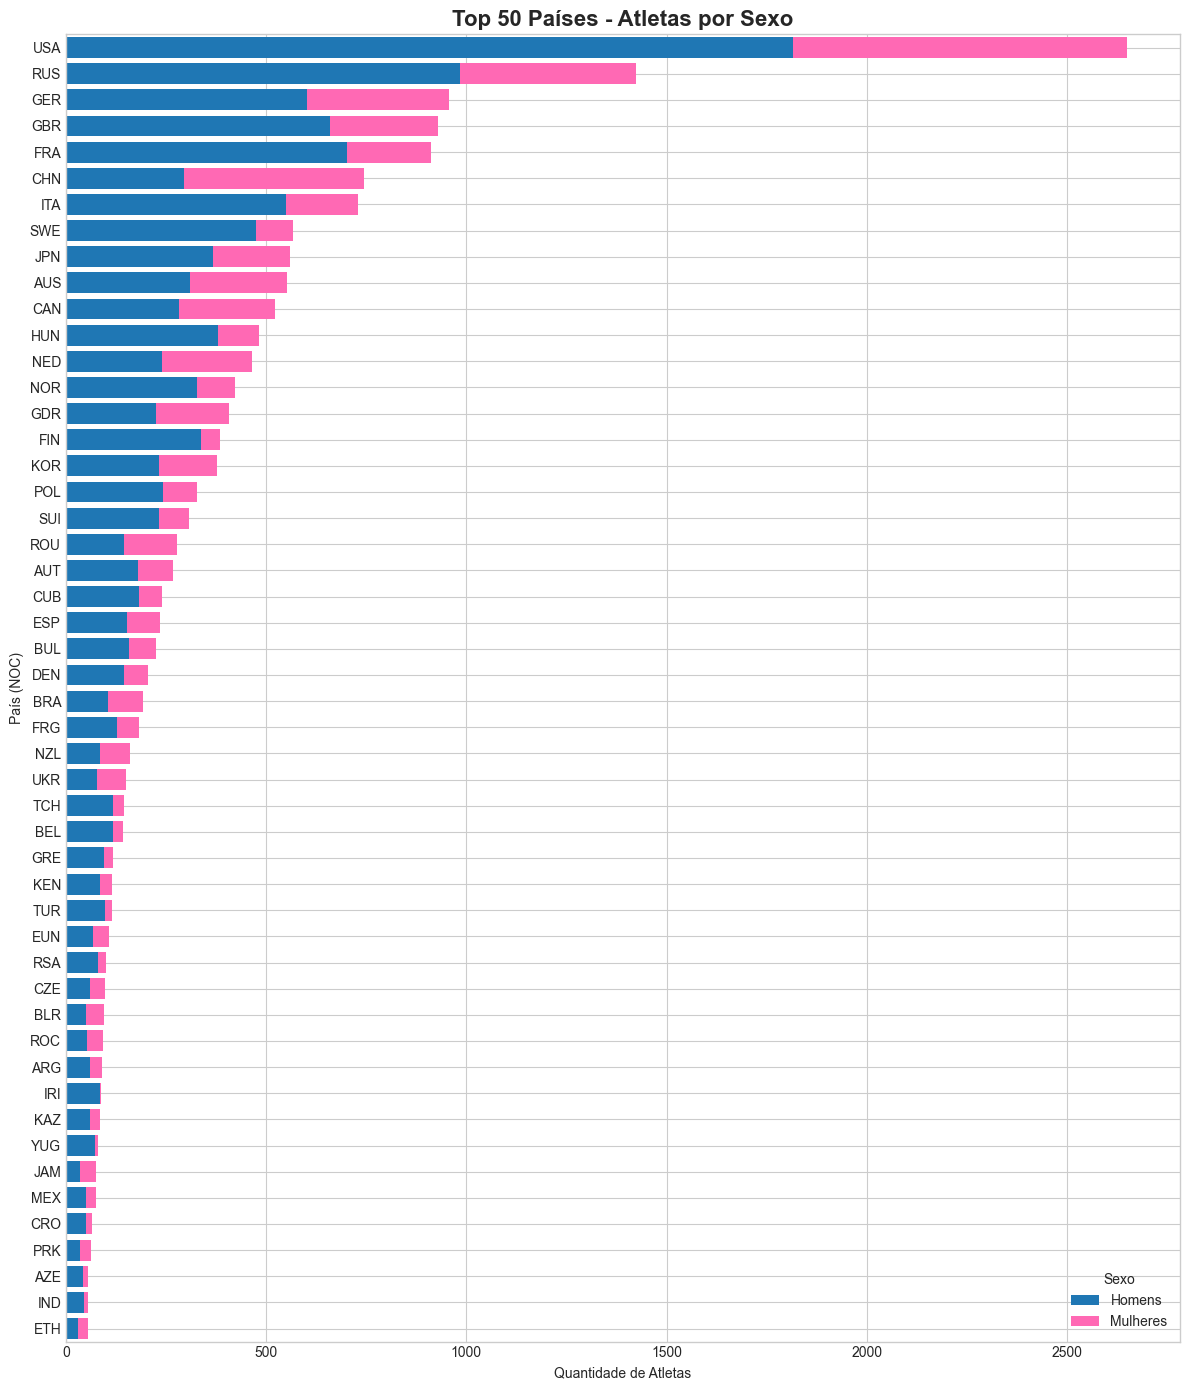

In [10]:
plot_top50_genero(
    df_genero,
    'Top 50 Países - Atletas por Sexo',
    'genero_plot.png'
)

In [11]:
totais = df_genero[
    ['male_athletes', 'female_athletes', 'Mixed', 'Open']
].sum()

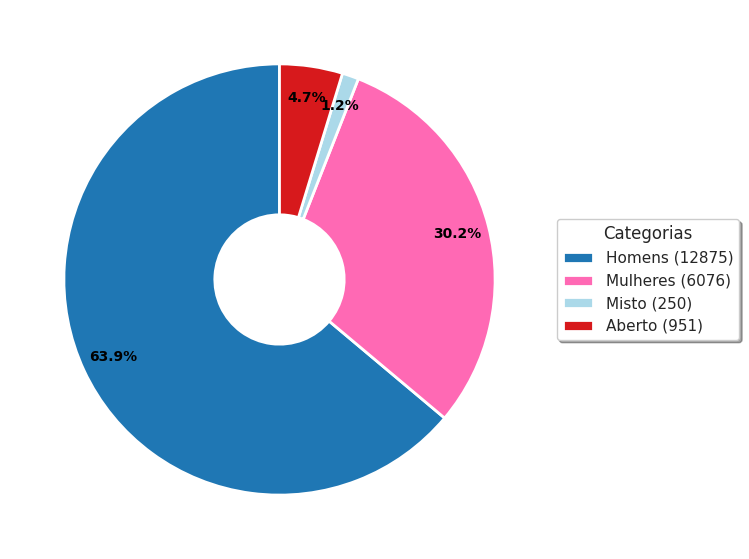

In [14]:
totais = [
    df_genero['male_athletes'].sum() if 'male_athletes' in df_genero else 0,
    df_genero['female_athletes'].sum() if 'female_athletes' in df_genero else 0,
    df_genero['Mixed'].sum() if 'Mixed' in df_genero else 0,
    df_genero['Open'].sum() if 'Open' in df_genero else 0
]
labels = ['Homens', 'Mulheres', 'Misto', 'Aberto']

# Cores personalizadas (paleta suave e moderna)
cores = ['#1f77b4', '#ff69b4', '#abd9e9', '#d7191c']  # azul, laranja, azul claro, vermelho
# Você também pode usar uma paleta do seaborn:
# import seaborn as sns
# cores = sns.color_palette("pastel", len(labels))

# Função para formatar os valores com percentual e número absoluto
def autopct_format(values):
    def my_format(pct):
        return f'{pct:.1f}%'
    return my_format

# Configurar figura
plt.figure(figsize=(9, 7))
plt.rcParams['font.family'] = 'DejaVu Sans'  # ou 'Arial', 'Helvetica'

# Criar o gráfico de rosca (donut)
wedges, texts, autotexts = plt.pie(
    totais,
    labels=None,               # removemos os labels diretos no gráfico
    colors=cores,
    autopct=autopct_format(totais),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.7},  # width 0.7 cria o efeito rosca
    pctdistance=0.85,          # distância dos percentuais do centro
    textprops={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'},
)

# Adicionar legenda personalizada (mais elegante)
labels_numeros = [f'{l} ({v})' for l, v in zip(labels, totais)]
plt.legend(
    wedges, labels_numeros,
    title="Categorias",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    title_fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True,
    edgecolor='#cccccc'
)

plt.savefig("../analise_genero/genero_pizza.png", dpi=300, bbox_inches='tight')

plt.show()